# Whose spend is falling, and is the quarter on plan?

**Week 2, Wednesday. Round 3 of 3: SQL window functions.** By the end of this notebook you can
compare each member's month with the member's own previous month, refuse to read a gap as a fall,
and build a running total that closes on the quarter's total and reads against the plan line.

> **Marketing asks.** "Flag anyone whose monthly spend has fallen for two months running. And Meera
> wants to see revenue accumulate week by week against the plan line, so we know by mid-quarter
> whether we are on track."

> **Kavya's review, at the end of this round.** "LAG reads the previous row, so partition by the
> member and check the previous row is last month. A running total is only as true as its order
> and its start: check it closes on the quarter's total."

Round 2 settled the tie rule: RANK inside each segment, with the count said out loud. This round
answers the other two parts of Marketing's ask. The flag means the member spent less in August than
in July, and less again in September than in August. The SQL behind every cell is
`sql/C2_W02_D03_03_falling_spend_STUDENT.sql`.

**Setup.** The first lines find `scripts/c2kit.py` by walking up from this folder and import it as
`kit`; the helper opens the Kalpa warehouse with the settings the Codespace exports. `sql` runs a
query through `kit.sql` and hands back rows whose amounts are plain Python numbers, `show` prints a
query's rows as a table with rupees in Indian grouping, and `Q2_PER_MEMBER` is Monday's definition
of Q2 revenue per member, the booked amount of the member's Q2 orders of every status, written once
so every query below starts from the same number.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import decimal


def show(rows, money=(), caption="", limit=15):
    """Query rows as the kit's table, with every rupee column in Indian grouping."""
    def cell(h, v):
        if v is None:
            return ""
        return kit.rupees(v) if h in money else str(v)
    headers = list(rows[0])
    body = [[cell(h, r[h]) for h in headers] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..."] * len(headers))
    kit.table(headers, body, caption or f"{len(rows)} rows")


def crore(v):
    """A large rupee figure on a chart axis, in crore, so the tick labels stay short."""
    return f"Rs {v / 1e7:.2f} cr"


Q2_PER_MEMBER = """
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id"""

SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]

def sql(query):
    """kit.sql with Postgres numerics turned into Python numbers, so charts and arithmetic take them."""
    def num(v):
        if isinstance(v, decimal.Decimal):
            return int(v) if v == v.to_integral_value() else float(v)
        return v
    return [{k: num(v) for k, v in row.items()} for row in kit.sql(query)]


first = sql("SELECT count(*) AS orders, sum(amount) FILTER (WHERE quarter = 'Q2') AS q2 FROM orders")[0]
print(f"The warehouse answered: {first['orders']:,} orders, Q2 booked {kit.rupees(first['q2'])}.")

MONTHLY = """
    SELECT customer_id, date_trunc('month', order_date)::date AS month, sum(amount) AS spend
    FROM   orders
    GROUP  BY customer_id, date_trunc('month', order_date)"""
MONTHS = ["2026-04-01", "2026-05-01", "2026-06-01", "2026-07-01", "2026-08-01", "2026-09-01"]
LABELS = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]

The warehouse answered: 1,000 orders, Q2 booked Rs 9,84,00,000.


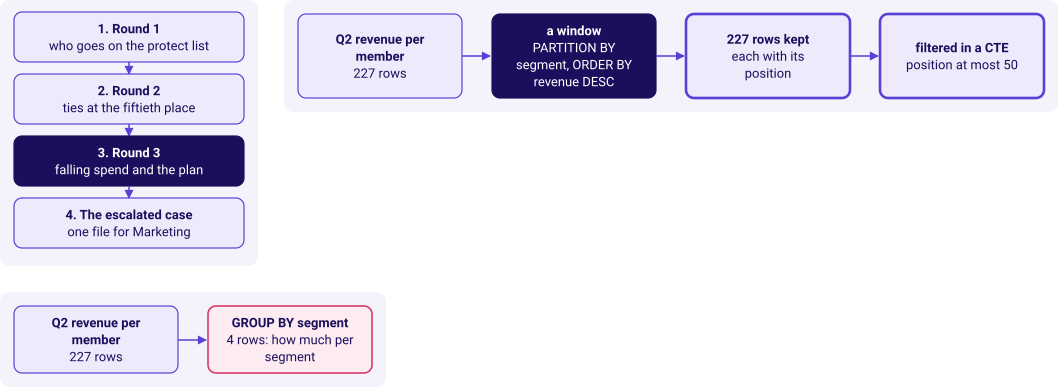

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1\nwho goes on the protect list",
                "Round 2\nties at the fiftieth place",
                "Round 3\nfalling spend and the plan",
                "The escalated case\none file for Marketing"], lit=2, show=False),
    kit.flow(["Q2 revenue per member\n227 rows",
              "a window\nPARTITION BY segment, ORDER BY revenue DESC",
              "227 rows kept\neach with its position",
              "filtered in a CTE\nposition at most 50"],
             kinds=["plain", "lit", "known", "known"], show=False),
    kit.flow(["Q2 revenue per member\n227 rows",
              "GROUP BY segment\n4 rows: how much per segment"],
             kinds=["plain", "bad"], show=False),
)

## 1. The monthly spend table has a row only for a month with an order

A fall is a comparison between months, so the first step builds one row per member per month,
April to September, from every order of both quarters. C-0010, Retail-Core's biggest Q2 member, is
the worked example, because the member's spend fell in the plain way: July, then August, then
September, each lower.

**Predict before you run.** What does the table hold for a month in which a member placed no order?
a) a row with spend 0; b) a row with spend NULL; c) no row at all; d) a copy of the previous month.

customer_id,month,spend
C-0010,2026-04-01,"Rs 1,710"
C-0010,2026-06-01,"Rs 4,060"
C-0010,2026-07-01,"Rs 7,840"
C-0010,2026-08-01,"Rs 4,080"
C-0010,2026-09-01,"Rs 1,990"


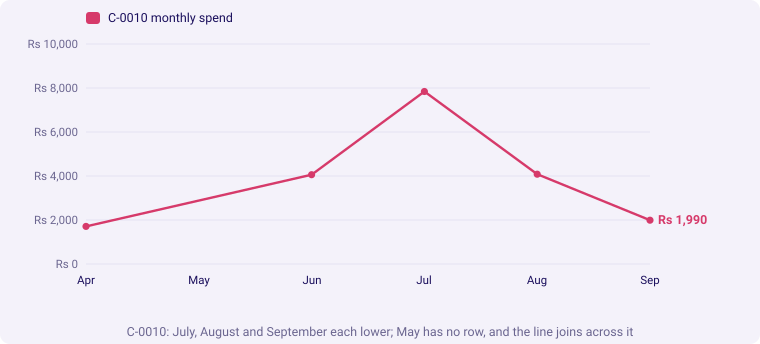

In [3]:
monthly = sql(MONTHLY + "\n    ORDER BY customer_id, month")
c0010 = [r for r in monthly if r["customer_id"] == "C-0010"]
show(c0010, money=("spend",), caption="C-0010, one row per month with an order")
by_month = {str(r["month"]): r["spend"] for r in c0010}
kit.line(LABELS, [("C-0010 monthly spend", [by_month.get(m) for m in MONTHS], "bad")], fmt=kit.rupees,
         title="C-0010: July, August and September each lower; May has no row, and the line joins across it")

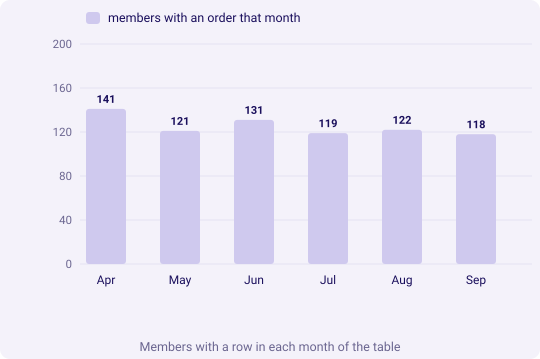

In [4]:
active = sql("""
    SELECT date_trunc('month', order_date)::date AS month, count(DISTINCT customer_id) AS members
    FROM   orders GROUP BY 1 ORDER BY 1""")
kit.columns(LABELS, [("members with an order that month", [r["members"] for r in active])],
            title="Members with a row in each month of the table")

**What happened.** The answer is c. C-0010 bought in April, June, July, August and September, and
the table has five rows for the member: May has no row at all. That absence is what the rest of the
round turns on. For C-0010 the three Q2 months read Rs 7,840, Rs 4,080 and Rs 1,990, a fall two
months running, and 118 members have a September row that could be compared at all.

In [5]:
kit.check("one row per member per month with an order",
          len(monthly) == len({(r["customer_id"], r["month"]) for r in monthly}), f"{len(monthly)} rows")
kit.check("C-0010 has five months and no May row", len(c0010) == 5 and "2026-05-01" not in by_month)
kit.check("C-0010 fell from Rs 7,840 to Rs 4,080 to Rs 1,990",
          [by_month[m] for m in MONTHS[3:]] == [7840, 4080, 1990])
kit.check("118 members have a September order", active[-1]["members"] == 118, str(active[-1]["members"]))

## 2. The trap: LAG without PARTITION BY compares a member with someone else

**The plausible wrong answer.** `lag(spend)` reads the previous row, so a hurried analyst sorts the
table by member and month and writes `lag(spend, 1) OVER (ORDER BY customer_id, month)` and
`lag(spend, 2)` beside it, then flags September rows where each month is below the one before.

**Predict before you run.** How many members does this flag? a) 16; b) 20; c) 9; d) 118.

flagged,compared_with_another_member,first_months_given_a_previous_value
20,4,300


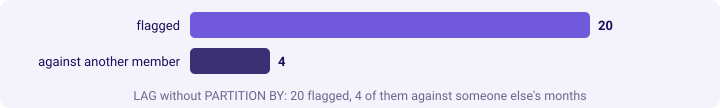

In [6]:
hurried = sql(f"""
    WITH monthly AS ({MONTHLY}),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1)       OVER (ORDER BY customer_id, month) AS spend_before,
               lag(spend, 2)       OVER (ORDER BY customer_id, month) AS spend_two_before,
               lag(customer_id, 1) OVER (ORDER BY customer_id, month) AS whose_row_before,
               lag(customer_id, 2) OVER (ORDER BY customer_id, month) AS whose_row_two_before
        FROM   monthly
    )
    SELECT (SELECT count(*) FROM lagged
            WHERE month = DATE '2026-09-01'
              AND spend < spend_before AND spend_before < spend_two_before) AS flagged,
           (SELECT count(*) FROM lagged
            WHERE month = DATE '2026-09-01'
              AND spend < spend_before AND spend_before < spend_two_before
              AND whose_row_two_before <> customer_id) AS compared_with_another_member,
           (SELECT count(*) FROM lagged
            WHERE whose_row_before <> customer_id) AS first_months_given_a_previous_value""")[0]
show([hurried], caption="The hurried flag, and two counts that should be zero")
kit.bars([("flagged", hurried["flagged"]),
          ("against another member", hurried["compared_with_another_member"])], lit=(1,),
         title="LAG without PARTITION BY: 20 flagged, 4 of them against someone else's months")

**What happened.** The answer is b, 20.

**Why it is wrong.** Without PARTITION BY the window is the whole table in one line, so the row
before a member's first month is the last month of whoever sorts before them. Four of the 20 had
their "fall" computed partly from another member's account, and Marketing would call a member about
a drop in spend that happened to somebody else. The tell is any member's first month carrying a
previous value; in a result of ten thousand rows the check is a count of rows where the row before
belongs to another customer, and it must be zero.

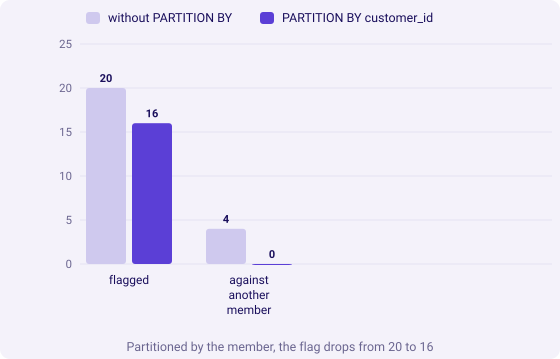

In [7]:
fixed = sql(f"""
    WITH monthly AS ({MONTHLY}),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_before,
               lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS spend_two_before,
               lag(month, 1) OVER (PARTITION BY customer_id ORDER BY month) AS month_before,
               lag(month, 2) OVER (PARTITION BY customer_id ORDER BY month) AS month_two_before
        FROM   monthly
    )
    SELECT count(*) AS flagged,
           count(*) FILTER (WHERE month_before <> DATE '2026-08-01'
                               OR month_two_before <> DATE '2026-07-01') AS a_gap_read_as_last_month
    FROM   lagged
    WHERE  month = DATE '2026-09-01'
      AND  spend < spend_before AND spend_before < spend_two_before""")[0]
kit.columns(["flagged", "against another member"],
            [("without PARTITION BY", [hurried["flagged"], hurried["compared_with_another_member"]]),
             ("PARTITION BY customer_id", [fixed["flagged"], 0])],
            title="Partitioned by the member, the flag drops from 20 to 16", width=560)
kit.check("the hurried flag counts 20", hurried["flagged"] == 20)
kit.check("4 of them compared with another member's month", hurried["compared_with_another_member"] == 4)
kit.check("first months carried a previous value without the partition",
          hurried["first_months_given_a_previous_value"] > 0,
          f'{hurried["first_months_given_a_previous_value"]} first months')
kit.check("PARTITION BY customer_id flags 16", fixed["flagged"] == 16)

**The fix.** `PARTITION BY customer_id` inside every LAG, so each member is compared only with the
member's own months. The flag goes from 20 members to 16, and none of the 16 borrows another
member's spend.

## 3. The trap: a skipped month read as last month

**The plausible wrong answer.** The partitioned flag says 16, and every comparison is now inside one
member's account. A member rings Marketing: "I was on holiday in August." C-0216 bought Rs 6,440 in
May, nothing in June, Rs 4,300 in July, nothing in August and Rs 2,540 in September, and sits on the
list of 16.

**Predict before you run.** For C-0216's September row, what does `lag(month)` call last month?
a) August; b) July; c) nothing, NULL; d) June.

customer_id,month,spend,the_row_lag_calls_last_month
C-0216,2026-05-01,"Rs 6,440",
C-0216,2026-07-01,"Rs 4,300",2026-05-01
C-0216,2026-09-01,"Rs 2,540",2026-07-01


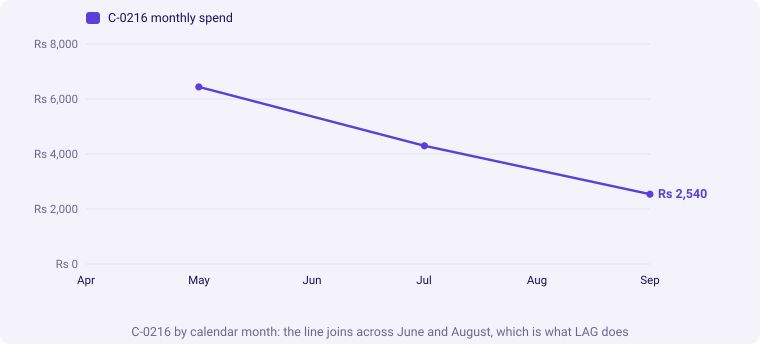

In [8]:
c0216 = sql(f"""
    WITH monthly AS ({MONTHLY})
    SELECT customer_id, month, spend,
           lag(month) OVER (PARTITION BY customer_id ORDER BY month) AS the_row_lag_calls_last_month
    FROM   monthly
    WHERE  customer_id = 'C-0216'
    ORDER  BY month""")
show(c0216, money=("spend",), caption="C-0216: the three rows LAG lines up")
seen = {str(r["month"]): r["spend"] for r in c0216}
kit.line(LABELS, [("C-0216 monthly spend", [seen.get(m) for m in MONTHS], "plain")], fmt=kit.rupees,
         title="C-0216 by calendar month: the line joins across June and August, which is what LAG does")

**What happened.** The answer is b. LAG reads the previous row, and C-0216 has no August row, so the
row before September is July, and the row before July is May. LAG saw May Rs 6,440, July Rs 4,300 and
September Rs 2,540, three falling readings, and called it two months running.

**Why it is wrong.** The member on holiday is right: two of the "months" in the run are gaps, and a
gap became a fall. Marketing would spend a retention call on a member whose August is simply
missing. The check carries `lag(month)` beside `lag(spend)` and counts the rows where the previous
row is not the previous calendar month.

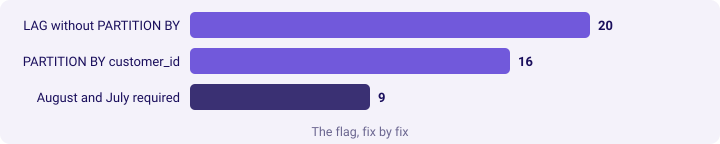

In [9]:
holds = sql(f"""
    WITH monthly AS ({MONTHLY}),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_before,
               lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS spend_two_before,
               lag(month, 1) OVER (PARTITION BY customer_id ORDER BY month) AS month_before,
               lag(month, 2) OVER (PARTITION BY customer_id ORDER BY month) AS month_two_before
        FROM   monthly
    )
    SELECT customer_id
    FROM   lagged
    WHERE  month = DATE '2026-09-01'
      AND  month_before     = month - INTERVAL '1 month'
      AND  month_two_before = month - INTERVAL '2 months'
      AND  spend < spend_before AND spend_before < spend_two_before""")
held = {r["customer_id"] for r in holds}
kit.bars([("LAG without PARTITION BY", 20), ("PARTITION BY customer_id", fixed["flagged"]),
          ("August and July required", len(held))], lit=(2,),
         title="The flag, fix by fix")
kit.check("7 of the 16 read a gap as last month", fixed["a_gap_read_as_last_month"] == 7)
kit.check("requiring August and July leaves 9", len(held) == 9, f"{len(held)} members")
kit.check("C-0216, the member on holiday, is not flagged", "C-0216" not in held)
kit.check("C-0010, a plain fall, stays flagged", "C-0010" in held)

**The fix.** Require the two previous rows to be August and July, so a month with no order is no
reading and breaks the run. The flag goes from 16 members to 9, and the 7 who dropped out each had a
gap where LAG had found a fall.

**Your turn.** The count is 9; the names are for you to read. Type these lines into the empty cell
below, run them, and say which segments the flagged members sit in:

```python
flagged = sql(f"""
    WITH monthly AS ({MONTHLY}),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_before,
               lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS spend_two_before,
               lag(month, 1) OVER (PARTITION BY customer_id ORDER BY month) AS month_before,
               lag(month, 2) OVER (PARTITION BY customer_id ORDER BY month) AS month_two_before
        FROM monthly)
    SELECT c.segment, l.customer_id, l.spend_two_before AS july, l.spend_before AS august, l.spend AS september
    FROM   lagged l JOIN customers c USING (customer_id)
    WHERE  l.month = DATE '2026-09-01'
      AND  l.month_before = l.month - INTERVAL '1 month'
      AND  l.month_two_before = l.month - INTERVAL '2 months'
      AND  l.spend < l.spend_before AND l.spend_before < l.spend_two_before
    ORDER  BY c.segment, l.customer_id""")
show(flagged, money=("july", "august", "september"))
```

## 4. A running total needs an unambiguous order and a start that covers the quarter

Meera wants revenue accumulating against the plan line. A running total is `sum(amount) OVER (ORDER
BY ...)`, and its ORDER BY decides what each row's step is. The busiest day of the quarter, 22 July,
carries twelve orders.

**Predict before you run.** With `ORDER BY order_date` alone, what running total does the first of
22 July's twelve orders show? a) the previous day's close plus its own amount; b) the day's closing
figure, the same on all twelve rows; c) NULL, because the order is ambiguous; d) a different figure
on every run.

order_date,order_id,amount,by_date_only,by_date_then_order
2026-07-22,KR-00557,Rs 930,"Rs 3,76,90,290","Rs 3,45,16,000"
2026-07-22,KR-00580,"Rs 8,55,000","Rs 3,76,90,290","Rs 3,53,71,000"
2026-07-22,KR-00601,"Rs 10,40,000","Rs 3,76,90,290","Rs 3,64,11,000"
2026-07-22,KR-00604,"Rs 10,42,000","Rs 3,76,90,290","Rs 3,74,53,000"
2026-07-22,KR-00607,"Rs 2,21,000","Rs 3,76,90,290","Rs 3,76,74,000"
2026-07-22,KR-00713,"Rs 3,240","Rs 3,76,90,290","Rs 3,76,77,240"
2026-07-22,KR-00761,"Rs 2,520","Rs 3,76,90,290","Rs 3,76,79,760"
2026-07-22,KR-00782,"Rs 2,250","Rs 3,76,90,290","Rs 3,76,82,010"
2026-07-22,KR-00832,"Rs 2,920","Rs 3,76,90,290","Rs 3,76,84,930"
2026-07-22,KR-00853,"Rs 2,150","Rs 3,76,90,290","Rs 3,76,87,080"


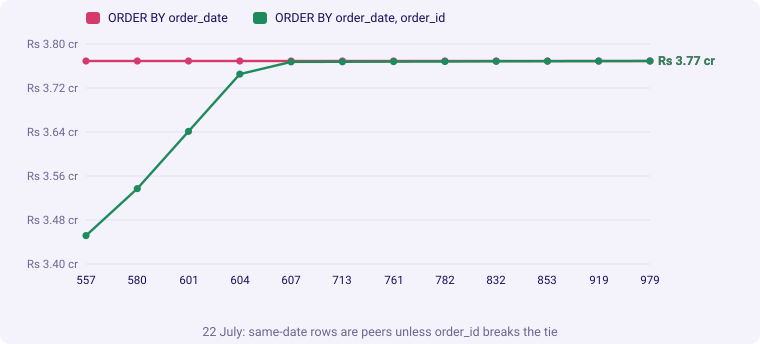

In [10]:
day = sql("""
    WITH running AS (
        SELECT order_date, order_id, amount,
               sum(amount) OVER (ORDER BY order_date)           AS by_date_only,
               sum(amount) OVER (ORDER BY order_date, order_id) AS by_date_then_order
        FROM   orders
        WHERE  quarter = 'Q2'
    )
    SELECT * FROM running WHERE order_date = DATE '2026-07-22' ORDER BY order_id""")
show(day, money=("amount", "by_date_only", "by_date_then_order"), caption="22 July, twelve orders")
kit.line([r["order_id"][-3:] for r in day],
         [("ORDER BY order_date", [r["by_date_only"] for r in day], "bad"),
          ("ORDER BY order_date, order_id", [r["by_date_then_order"] for r in day], "good")],
         fmt=crore, lo=34000000, title="22 July: same-date rows are peers unless order_id breaks the tie")

**What happened.** The answer is b. With a date alone, the twelve orders of 22 July are peers, and
Postgres gives every peer the running total at the end of the peer group, Rs 3,76,90,290, the day's
closing figure. With `order_id` as a tiebreaker each row is one step, from Rs 3,45,16,000 after the
first order of the day to Rs 3,76,90,290 after the last, and the same steps on every run.

In [11]:
kit.check("22 July carries twelve Q2 orders", len(day) == 12)
kit.check("by date alone, all twelve show one figure", len({r["by_date_only"] for r in day}) == 1)
kit.check("with order_id, twelve distinct steps", len({r["by_date_then_order"] for r in day}) == 12)
kit.check("the steps run from Rs 3,45,16,000 to Rs 3,76,90,290",
          day[0]["by_date_then_order"] == 34516000 and day[-1]["by_date_then_order"] == 37690290)

Now against the plan. `plan_line` has thirteen weeks starting Monday 6 July, Rs 75,69,230 each. Both
sides accumulate, and the actual is read at each plan week's last day, `week_start + 6`, so orders
placed before the plan's first week still count.

**Predict before you run.** At mid-quarter, the end of the seventh plan week, where did Q2 stand?
a) behind plan; b) on plan within a lakh; c) ahead by about Rs 1.58 crore; d) at nine times the plan.

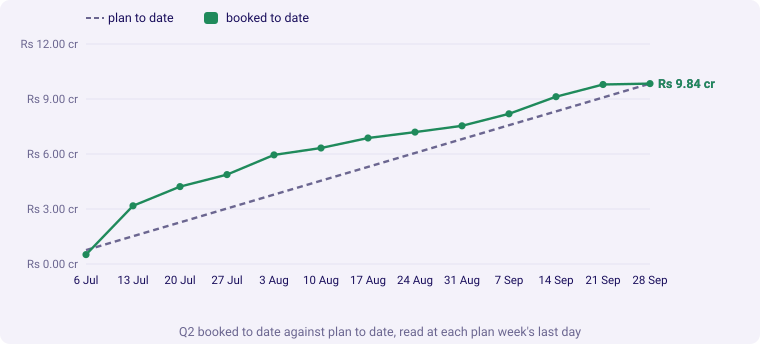

week_start,plan_to_date,booked_to_date,ahead_of_plan
2026-07-06,"Rs 75,69,230","Rs 51,00,180","-Rs 24,69,050"
2026-07-13,"Rs 1,51,38,460","Rs 3,17,29,100","Rs 1,65,90,640"
2026-07-20,"Rs 2,27,07,690","Rs 4,22,44,480","Rs 1,95,36,790"
2026-07-27,"Rs 3,02,76,920","Rs 4,87,81,050","Rs 1,85,04,130"
2026-08-03,"Rs 3,78,46,150","Rs 5,95,15,810","Rs 2,16,69,660"
2026-08-10,"Rs 4,54,15,380","Rs 6,32,84,780","Rs 1,78,69,400"
2026-08-17,"Rs 5,29,84,610","Rs 6,87,36,590","Rs 1,57,51,980"
2026-08-24,"Rs 6,05,53,840","Rs 7,19,59,570","Rs 1,14,05,730"
2026-08-31,"Rs 6,81,23,070","Rs 7,53,96,740","Rs 72,73,670"
2026-09-07,"Rs 7,56,92,300","Rs 8,19,30,010","Rs 62,37,710"


In [12]:
plan = sql("""
    WITH daily AS (
        SELECT order_date, sum(amount) AS booked FROM orders WHERE quarter = 'Q2' GROUP BY order_date
    ),
    to_date AS (
        SELECT order_date, sum(booked) OVER (ORDER BY order_date) AS booked_to_date FROM daily
    ),
    plan AS (
        SELECT week_start, week_start + 6 AS week_end, plan_revenue,
               sum(plan_revenue) OVER (ORDER BY week_start) AS plan_to_date
        FROM   plan_line
    )
    SELECT p.week_start, p.plan_revenue, p.plan_to_date,
           (SELECT max(t.booked_to_date) FROM to_date t WHERE t.order_date <= p.week_end) AS booked_to_date
    FROM   plan p
    ORDER  BY p.week_start""")
for r in plan:
    r["ahead_of_plan"] = r["booked_to_date"] - r["plan_to_date"]
weeks = [r["week_start"].strftime("%d %b").lstrip("0") for r in plan]
kit.line(weeks, [("plan to date", [r["plan_to_date"] for r in plan], "plan"),
                 ("booked to date", [r["booked_to_date"] for r in plan], "good")],
         fmt=crore, title="Q2 booked to date against plan to date, read at each plan week's last day")
show([{k: r[k] for k in ("week_start", "plan_to_date", "booked_to_date", "ahead_of_plan")} for r in plan],
     money=("plan_to_date", "booked_to_date", "ahead_of_plan"), caption="The thirteen plan weeks")

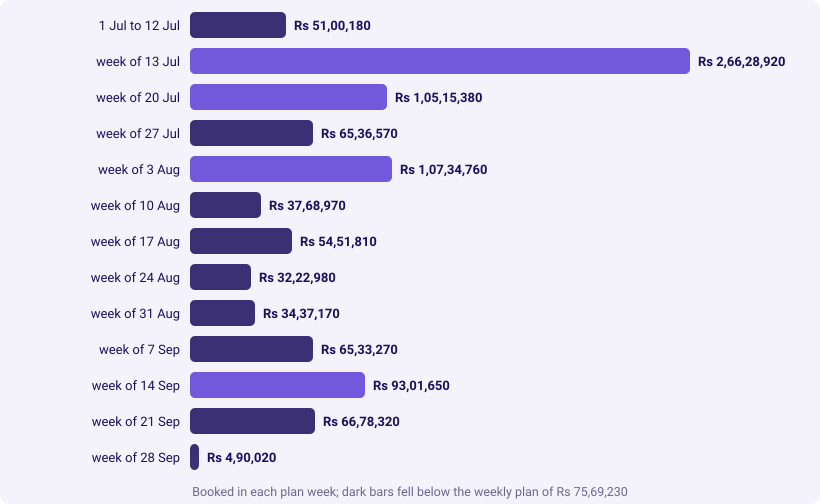

In [13]:
weekly = [plan[0]["booked_to_date"]] + [plan[i]["booked_to_date"] - plan[i - 1]["booked_to_date"]
                                        for i in range(1, len(plan))]
kit.bars([("1 Jul to 12 Jul" if i == 0 else f"week of {w}", v) for i, (w, v) in enumerate(zip(weeks, weekly))],
         fmt=kit.rupees,
         lit=[i for i, v in enumerate(weekly) if v < plan[i]["plan_revenue"]], width=820,
         title="Booked in each plan week; dark bars fell below the weekly plan of Rs 75,69,230")

**What happened.** The answer is c. At the end of the seventh plan week, the week of 17 August, Q2
had booked Rs 6,87,36,590 against a plan to date of Rs 5,29,84,610, ahead by Rs 1,57,51,980. Almost
all of that lead came from the week of 13 July, which booked Rs 2.66 crore on its own. From the week
of 10 August, six of the seven full weeks booked below the weekly plan, and the lead shrank from a
peak of Rs 2,16,69,660 to Rs 10 at the close: Rs 9,84,00,000 against Rs 9,83,99,990. On track by the
total, off track by the run rate. Option d is what a dashboard shows when it sets the running actual
beside one week's plan instead of the plan to date.

In [14]:
ahead = [r["ahead_of_plan"] for r in plan]
kit.check("thirteen plan weeks", len(plan) == 13)
kit.check("booked to date closes on Monday's Q2 total", plan[-1]["booked_to_date"] == 98400000,
          kit.rupees(plan[-1]["booked_to_date"]))
kit.check("the plan closes at Rs 9,83,99,990", plan[-1]["plan_to_date"] == 98399990)
kit.check("ahead by Rs 1,57,51,980 at mid-quarter", ahead[6] == 15751980, kit.rupees(ahead[6]))
kit.check("the lead peaked at Rs 2,16,69,660", max(ahead) == 21669660)
kit.check("six of the seven full weeks from 10 August booked below plan",
          sum(1 for i in range(5, 12) if weekly[i] < plan[i]["plan_revenue"]) == 6)

## What this round established

> **Kavya's review.** "LAG reads the previous row, so partition by the member and check the previous
> row is last month. A running total is only as true as its order and its start: check it closes on
> the quarter's total before anybody reads the chart."

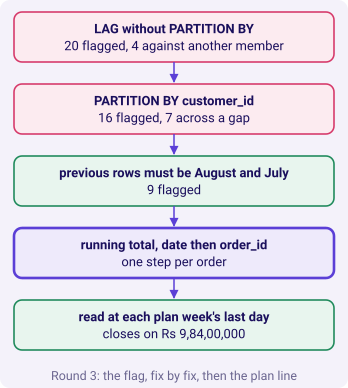

Question,Answer,What it means for Marketing and Meera
Flagged by the hurried LAG?,20,Four calls about someone else's fall.
Flagged with the member partition?,16,Seven of them read a holiday as a fall.
Flagged with consecutive months?,9,The list Marketing can defend.
Ahead of plan at mid-quarter?,"Rs 1,57,51,980",Almost all of it from one July week.
Where did Q2 close?,"Rs 9,84,00,000",Rs 10 ahead of the plan line.


In [15]:
kit.vflow(["LAG without PARTITION BY\n20 flagged, 4 against another member",
           "PARTITION BY customer_id\n16 flagged, 7 across a gap",
           "previous rows must be August and July\n9 flagged",
           "running total, date then order_id\none step per order",
           "read at each plan week's last day\ncloses on Rs 9,84,00,000"],
          kinds=["bad", "bad", "good", "known", "good"],
          title="Round 3: the flag, fix by fix, then the plan line")
kit.table(["Question", "Answer", "What it means for Marketing and Meera"],
          [("Flagged by the hurried LAG?", "20", "Four calls about someone else's fall."),
           ("Flagged with the member partition?", "16", "Seven of them read a holiday as a fall."),
           ("Flagged with consecutive months?", "9", "The list Marketing can defend."),
           ("Ahead of plan at mid-quarter?", kit.rupees(ahead[6]), "Almost all of it from one July week."),
           ("Where did Q2 close?", kit.rupees(plan[-1]["booked_to_date"]), "Rs 10 ahead of the plan line.")],
          caption="What Round 3 established")

### In the interview

**[F] How would you find customers whose spend fell two months in a row?** "I build one row per
customer per month, then use `lag(spend, 1)` and `lag(spend, 2)` over `PARTITION BY customer_id ORDER
BY month`, and keep the latest month where spend is below the month before and that is below the
month before it. I also carry `lag(month)` beside `lag(spend)` and require the previous rows to be the
previous two calendar months, because LAG reads the previous row, and a customer with no order in
August has July as the previous row. Without that condition a gap becomes a fall."

**[F] LAG returned a value for a customer's very first month. What went wrong, and how do you check
for it in a result of ten thousand rows?** "The window is missing PARTITION BY customer_id, so the
previous row belongs to whoever sorts before that customer. I check it with a count, never by eye: I
carry `lag(customer_id)` beside the value and count rows where it differs from the current customer.
With the partition in place that count is zero, and so is the count of first months with a non-null
previous value."

**[D] A member says he was on holiday in August and should not be flagged. How does your definition
treat a month with no orders, and why not fill it with zero?** "My definition treats a month with no
order as no reading, so it breaks the run and the member is not flagged: a fall needs three readings a
calendar month apart. Filling the gap with zero would turn every holiday into a fall to zero and flag
anyone who skipped September, which is a different question, lapsed members, and deserves its own
list with its own name."

**[F] What makes a running total deterministic, and how would you notice one that was not?** "An
ORDER BY in the window that gives every row a unique place, which usually means adding a key like
order_id after the date. With the date alone, rows on the same date are peers and all show the day's
closing figure. I notice it when several rows share one running value, or when a row-level running
total differs between two runs, and I check that the last value equals the plain sum."

**[F] A dashboard says revenue to date is nine times the plan by week seven. What is the likely
mistake?** "It is comparing a running total with one week's plan. Booked to date at week seven was
Rs 6,87,36,590 and a single week's plan is Rs 75,69,230, which is about nine times. Both sides have to
accumulate: the plan to date at week seven was Rs 5,29,84,610, so the business was ahead by
Rs 1,57,51,980, a long way from nine times."

### Depth: why zero-filling a gap is no fix

The tempting repair for the holiday member is to give every member a row for every month, with 0 where
there was no order, and let LAG run over a complete calendar. It makes the gaps disappear from view
and changes the question. A member who bought in July and August and was away in September now reads
as a fall to zero, and so does every member who simply stopped at the end of August. The invented
member below, labelled invented, spent Rs 5,000 in July and Rs 3,000 in August and placed no order in
September; zero-filled, the member is flagged. On Kalpa's months the zero-filled flag counts 26
members, and every one of the 17 it adds to the nine placed no September order at all.

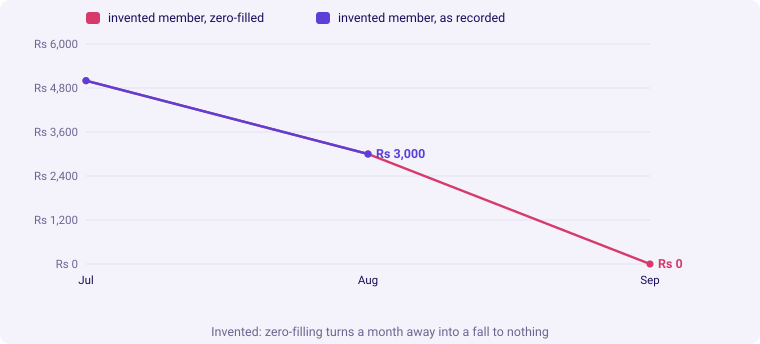

flagged,no_september_order
26,17


In [16]:
kit.line(["Jul", "Aug", "Sep"],
         [("invented member, zero-filled", [5000, 3000, 0], "bad"),
          ("invented member, as recorded", [5000, 3000, None], "plain")],
         fmt=kit.rupees, title="Invented: zero-filling turns a month away into a fall to nothing")
zero = sql(f"""
    WITH months AS (
        SELECT generate_series(DATE '2026-04-01', DATE '2026-09-01', INTERVAL '1 month')::date AS month
    ),
    members AS (SELECT DISTINCT customer_id FROM orders),
    monthly AS ({MONTHLY}),
    filled AS (
        SELECT m.customer_id, mo.month, coalesce(x.spend, 0) AS spend
        FROM   members m CROSS JOIN months mo
        LEFT   JOIN monthly x ON x.customer_id = m.customer_id AND x.month = mo.month
    ),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_before,
               lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS spend_two_before
        FROM   filled
    )
    SELECT count(*) AS flagged, count(*) FILTER (WHERE spend = 0) AS no_september_order
    FROM   lagged
    WHERE  month = DATE '2026-09-01' AND spend < spend_before AND spend_before < spend_two_before""")[0]
show([zero], caption="The zero-filled flag on Kalpa's months")
kit.check("zero-filling flags more members than the consecutive-month rule", zero["flagged"] > len(held),
          f'{zero["flagged"]} against {len(held)}')
kit.check("every member zero-filling adds bought nothing in September",
          zero["no_september_order"] == zero["flagged"] - len(held) == 17)

In [17]:
kit.check_summary()
print("Next: the escalated case puts the list, the flag and the plan line into one file for Marketing.")

Next: the escalated case puts the list, the flag and the plan line into one file for Marketing.
